**Cell 1: Install**

In [22]:
!pip install networkx matplotlib PyPDF2 scipy numpy


  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


** Cell 2: Imports**

In [24]:
import os
import re
import networkx as nx
import matplotlib.pyplot as plt
from PyPDF2 import PdfReader

In [ ]:
import os

# Current working directory
cwd = os.getcwd()
print(f" Current Working Directory:\n{cwd}")

# Files in current directory
print("\n Files in current folder:")
try:
    for item in os.listdir(cwd):
        print(f"  - {item}")
except Exception as e:
    print(f" Error reading current folder: {e}")

# Check data folder
data_path = os.path.join(cwd, "data_docum")

print(f"\n Looking for data folder at:\n{data_path}")

if os.path.isdir(data_path):
    print("\n data folder found!")

    try:
        files = os.listdir(data_path)

        if files:
            print("\n Files inside data folder:")
            for file in files:
                print(f"  - {file}")
        else:
            print("\n data folder is empty.")

    except Exception as e:
        print(f"\n Error reading data folder: {e}")

else:
    print("\n data folder NOT found.")
    print(" Make sure the 'data' folder exists in the same directory as your script.")

📁 Current Working Directory:
c:\Users\hp\OneDrive\Desktop\RR\GRAPH_RAG_notebook_code_simple\rag_2_document

📂 Files in current folder:
  - .env
  - data_docum
  - document_graph.ipynb

📂 Looking for data folder at:
c:\Users\hp\OneDrive\Desktop\RR\GRAPH_RAG_notebook_code_simple\rag_2_document\data_docum

✅ data folder found!

📄 Files inside data folder:
  - combustion_process_60_pages.pdf
  - engine_system_60_pages.pdf
  - fuel_system_60_pages.pdf
  - testing_system_60_pages.pdf


Cell 3: Load PDFs

In [29]:
import os
from PyPDF2 import PdfReader

#  Correct folder name
pdf_files = [
    "data_docum/combustion_process_60_pages.pdf",
    "data_docum/engine_system_60_pages.pdf",
    "data_docum/fuel_system_60_pages.pdf",
    "data_docum/testing_system_60_pages.pdf"
]

def extract_text_from_pdfs(pdf_paths):
    all_texts = {}

    for path in pdf_paths:
        print(f"\n Processing: {path}")

        #  Check if file exists
        if not os.path.exists(path):
            print(f" File NOT FOUND: {path}")
            continue

        try:
            reader = PdfReader(path)
            text = ""

            for i, page in enumerate(reader.pages):
                page_text = page.extract_text()

                if page_text:
                    text += page_text + "\n"

            all_texts[os.path.basename(path)] = text

            print(f" Loaded: {os.path.basename(path)} | Pages: {len(reader.pages)}")

        except Exception as e:
            print(f" Error reading {path}: {e}")

    return all_texts


#  Run extraction
documents = extract_text_from_pdfs(pdf_files)

print("\n Final Loaded Documents:")
print(documents.keys())


 Processing: data_docum/combustion_process_60_pages.pdf
 Loaded: combustion_process_60_pages.pdf | Pages: 60

 Processing: data_docum/engine_system_60_pages.pdf
 Loaded: engine_system_60_pages.pdf | Pages: 60

 Processing: data_docum/fuel_system_60_pages.pdf
 Loaded: fuel_system_60_pages.pdf | Pages: 60

 Processing: data_docum/testing_system_60_pages.pdf
 Loaded: testing_system_60_pages.pdf | Pages: 60

 Final Loaded Documents:
dict_keys(['combustion_process_60_pages.pdf', 'engine_system_60_pages.pdf', 'fuel_system_60_pages.pdf', 'testing_system_60_pages.pdf'])


Cell 4: FINAL CLEAN RDF TRIPLE EXTRACTION

In [30]:
import re

def clean_entity(text):
    text = re.sub(r'[^\w\s]', '', text)

    stop_words = {"the", "a", "an", "and", "or", "of", "to"}
    words = text.lower().split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words).title()


def normalize_relation(rel, obj):
    # fix "consists of"
    if rel == "consists" and obj.lower().startswith("of"):
        return "consists_of"
    return rel


def clean_object(text):
    text = re.sub(r'[^\w\s]', '', text)

    words = text.split()

    # keep only first 3 meaningful words
    return " ".join(words[:3]).title()


def extract_triples_rdf_final(documents):
    triples = []
    seen = set()

    valid_relations = [
        "uses", "produces", "supplies", "drives",
        "consists", "compresses", "feeds",
        "includes", "delivers", "monitors", "measures",
        "controls", "connects", "generates", "converts"
    ]

    #  remove weak entities
    invalid_subjects = {
        "and", "or", "gases", "chamber", "system",
        "components", "pressure"
    }

    for source, text in documents.items():
        lines = text.split("\n")

        for line in lines:
            line = line.strip()

            if len(line) < 10:
                continue

            for rel in valid_relations:
                if rel in line.lower():

                    try:
                        parts = re.split(rel, line, flags=re.IGNORECASE)

                        if len(parts) < 2:
                            continue

                        # SUBJECT
                        subject_words = parts[0].strip().split()
                        subject = " ".join(subject_words[-2:])
                        subject = clean_entity(subject)

                        if subject.lower() in invalid_subjects:
                            continue

                        # OBJECT
                        obj_raw = parts[1].strip()
                        obj = clean_object(obj_raw)

                        if len(obj) < 3:
                            continue

                        # RELATION FIX
                        rel_fixed = normalize_relation(rel, obj_raw)

                        triple = (subject, rel_fixed, obj, source)

                        if triple not in seen:
                            seen.add(triple)
                            triples.append(triple)

                    except:
                        continue

    return triples


#  Run final extraction
triples = extract_triples_rdf_final(documents)

print("\n FINAL REFINED RDF TRIPLES:\n")
for t in triples[:25]:
    print(t)


 FINAL REFINED RDF TRIPLES:

('Combustion', 'uses', 'Air', 'combustion_process_60_pages.pdf')
('Combustion', 'uses', 'Fuel', 'combustion_process_60_pages.pdf')
('Combustion', 'produces', 'Heat', 'combustion_process_60_pages.pdf')
('Combustion', 'generates', 'High Pressure Gases', 'combustion_process_60_pages.pdf')
('Fuel System', 'supplies', 'Fuel To Combustion', 'combustion_process_60_pages.pdf')
('Compressor', 'supplies', 'Air To Combustion', 'combustion_process_60_pages.pdf')
('Combustion', 'drives', 'Turbine', 'combustion_process_60_pages.pdf')
('It', 'consists_of', 'Of Multiple Components', 'engine_system_60_pages.pdf')
('Compressor', 'compresses', 'Incoming Air To', 'engine_system_60_pages.pdf')
('Shaft', 'connects', 'Rotating Components And', 'engine_system_60_pages.pdf')
('Fuel System', 'supplies', 'Fuel Through Injectors', 'engine_system_60_pages.pdf')
('Engine', 'consists', '_Of Compressor', 'engine_system_60_pages.pdf')
('Engine', 'consists', '_Of Turbine', 'engine_system_6

** Cell 5: Build Graph **

In [31]:
def build_graph(triples):
    G = nx.DiGraph()

    for subj, rel, obj, source in triples:
        G.add_node(subj)
        G.add_node(obj)

        G.add_edge(subj, obj, relation=rel, source=source)

    return G


graph = build_graph(triples)

print("Nodes:", len(graph.nodes()))
print("Edges:", len(graph.edges()))

Nodes: 28
Edges: 24


NLP**

In [13]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


** PageRank (Ranking) **

In [32]:
pagerank_scores = nx.pagerank(graph)

for node, score in pagerank_scores.items():
    graph.nodes[node]['pagerank'] = score

top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:10]

print("\n🔥 Top Important Nodes:")
for node, score in top_nodes:
    print(node, ":", round(score, 4))


🔥 Top Important Nodes:
Rotating Components And : 0.0709
Combustion Chamber : 0.0532
Shaft : 0.0525
Fuel Lines : 0.0525
Air : 0.0383
Of Multiple Components : 0.0375
Engine : 0.0375
Various Parameters Such : 0.0375
Sensors : 0.0375
_Of Compressor : 0.0369


** Cell 7: Graph Retrieval (Multi-hop) **

In [33]:
def graph_retrieval(graph, query, max_hops=2, top_k=10):
    query = query.lower()
    results = []

    for node in graph.nodes():
        if node.lower() in query:

            paths = nx.single_source_shortest_path_length(graph, node, cutoff=max_hops)

            for target in paths:
                for neighbor in graph.neighbors(target):

                    rel = graph[target][neighbor]['relation']
                    score = graph.nodes[neighbor].get('pagerank', 0)

                    results.append((score, f"{target} --{rel}--> {neighbor}"))

    results = sorted(results, key=lambda x: x[0], reverse=True)

    return "\n".join([r[1] for r in results[:top_k]])

** Cell 8: Test Query **

In [34]:
query = "How fuel system works with combustion?"

context = graph_retrieval(graph, query)

print("\n📄 Retrieved Context:\n")
print(context)


📄 Retrieved Context:

Shaft --connects--> Rotating Components And
Fuel System --feeds--> Combustion Chamber
Turbine --drives--> Shaft
Fuel Pump --supplies--> Fuel Lines
Combustion --uses--> Air
It --consists_of--> Of Multiple Components
It --monitors--> Various Parameters Such
Combustion --uses--> Fuel
Combustion --produces--> Heat
Combustion --generates--> High Pressure Gases


** Cell 9: Graph Visualization **

C:\Users\hp\AppData\Local\Temp\ipykernel_11032\2231085620.py:50: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hp\OneDrive\Desktop\RR\GRAPH_RAG_notebook_code_simple\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


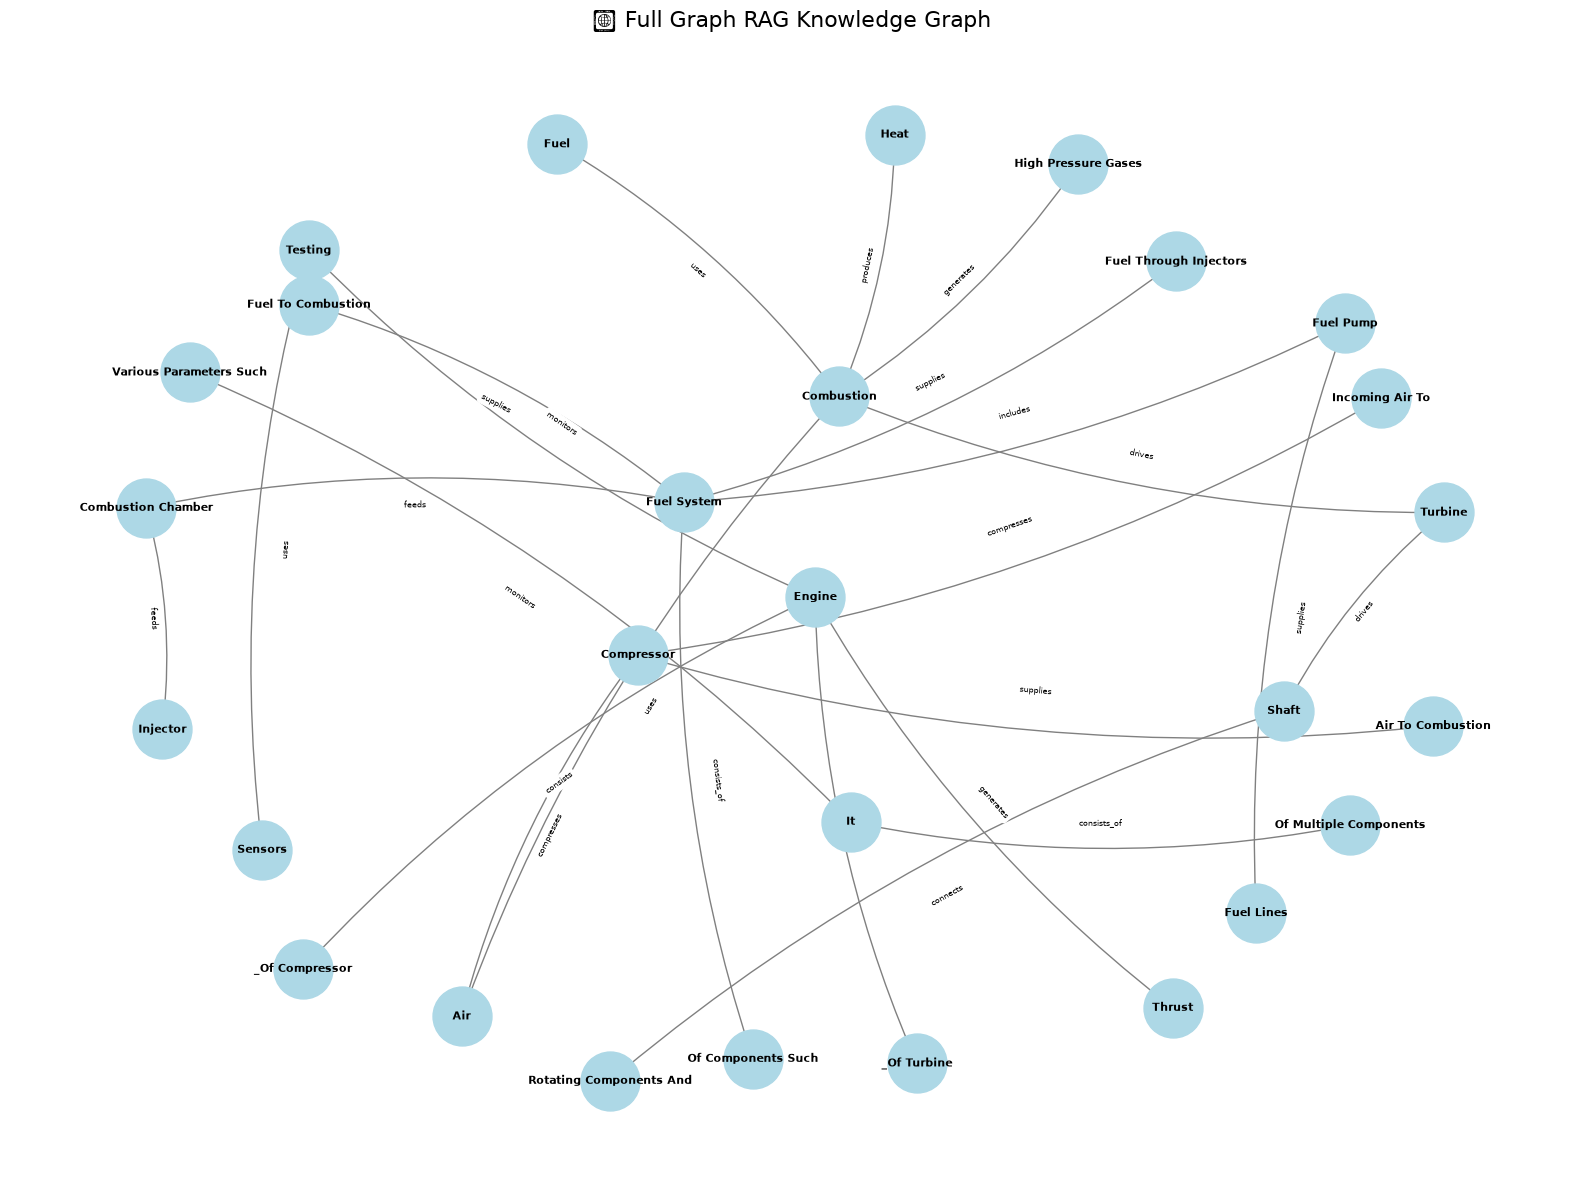

In [ ]:
def visualize_full_graph_clean(graph):
    plt.figure(figsize=(16, 12))

    #  Use spring layout with strong spacing
    pos = nx.spring_layout(
        graph,
        k=2.5,        # spacing between nodes (VERY IMPORTANT)
        iterations=100
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=1800,
        node_color="lightblue"
    )

    # Draw edges with curve (avoid overlap)
    nx.draw_networkx_edges(
        graph,
        pos,
        arrowstyle="->",
        arrowsize=15,
        edge_color="gray",
        connectionstyle="arc3,rad=0.1"   #  curve edges
    )

    # Draw node labels (smaller font)
    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=8,
        font_weight="bold"
    )

    # Edge labels (smaller + rotated)
    edge_labels = nx.get_edge_attributes(graph, 'relation')

    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=6,
        rotate=True
    )

    plt.title(" Full Graph RAG Knowledge Graph ", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


#  Run
visualize_full_graph_clean(graph)

Cell: LLM Setup

In [18]:
from openai import AzureOpenAI
import os
from dotenv import load_dotenv

load_dotenv()



client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version="2024-12-01-preview"
)

DEPLOYMENT_NAME = os.getenv("AZURE_OPENAI_DEPLOYMENT")

FINAL CELL: Graph RAG + LLM Answer

In [19]:
def graph_rag_answer(graph, query):
    
    # Step 1: Retrieve context from graph
    context = graph_retrieval(graph, query)

    print("\n🔍 Retrieved Context:\n")
    print(context)

    # Step 2: Create prompt
    prompt = f"""
You are an expert system engineer.

Answer the question using ONLY the context below.

Context:
{context}

Question:
{query}

Answer clearly and concisely:
"""

    # Step 3: Call LLM
    response = client.chat.completions.create(
        model=DEPLOYMENT_NAME,
        messages=[
            {"role": "system", "content": "You are a helpful AI assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3
    )

    answer = response.choices[0].message.content

    return answer

TEST FINAL SYSTEM

In [20]:
query = "How fuel system works with combustion?"

answer = graph_rag_answer(graph, query)

print("\n🤖 FINAL ANSWER:\n")
print(answer)


🔍 Retrieved Context:

Shaft --connects--> Rotating Components And
Fuel System --feeds--> Combustion Chamber
Turbine --drives--> Shaft
Fuel Pump --supplies--> Fuel Lines
Combustion --uses--> Air
It --consists_of--> Of Multiple Components
It --monitors--> Various Parameters Such
Combustion --uses--> Fuel
Combustion --produces--> Heat
Combustion --generates--> High Pressure Gases

🤖 FINAL ANSWER:

The fuel system feeds fuel to the combustion chamber, where the combustion process uses both air and fuel to produce heat and generate high-pressure gases.


Pratice** **


In [21]:
def visualize_multihop_graph(graph, query, hops=2):
    sub_nodes = set()

    query = query.lower()

    for node in graph.nodes():
        if node.lower() in query:
            paths = nx.single_source_shortest_path_length(graph, node, cutoff=hops)
            sub_nodes.update(paths.keys())

    subgraph = graph.subgraph(sub_nodes)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subgraph, k=1.5)

    nx.draw(subgraph, pos, with_labels=True, node_size=2500, node_color="lightblue")

    edge_labels = nx.get_edge_attributes(subgraph, 'relation')
    nx.draw_networkx_edge_labels(subgraph, pos, edge_labels=edge_labels)

    plt.title("🔗 Multi-Hop Subgraph")
    plt.show()

c:\Users\hp\OneDrive\Desktop\RR\GRAPH_RAG_notebook_code_simple\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


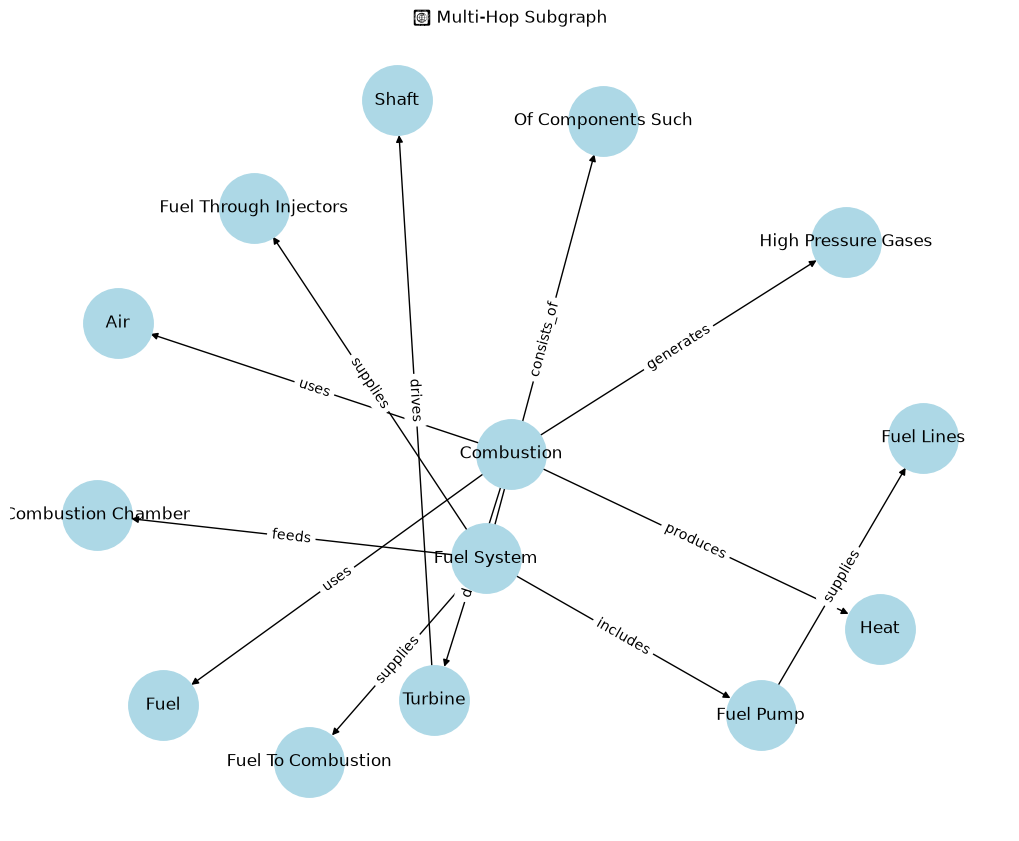

In [22]:
visualize_multihop_graph(graph, "fuel system combustion", hops=2)